In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import lmfit as lmf
from scipy.special import erfc
from scipy import interpolate
from scipy.special import spence

photon waveform

In [3]:
time = np.linspace(-1000, 1000, 1000)
const = 2.5e-3 * 2 * np.pi

def sech_0(time, const):
    return (const/2)**0.5/np.cosh(const*time)

def sech_1(time, const):
    return (6*const**3/(np.pi**2))**0.5/np.cosh(const*time)*time

def sech_2(time, const):
    return (45*(2*const)**5/64/(np.pi**4))**0.5/np.cosh(const*time)*(time**2-(np.pi/2/const)**2/3)

def sech_3(time, const):
    return (175*(2*const)**7)**0.5/24/(np.pi**3)/np.cosh(const*time)*(time**3-(7*time*(np.pi/(2*const))**2/5))

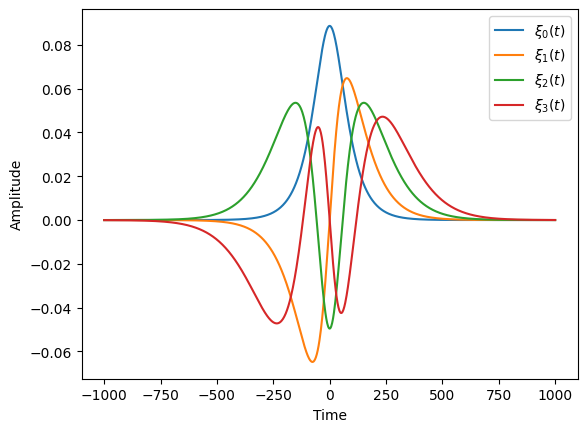

In [4]:
plt.plot(time, sech_0(time, const), label=r"$\xi_0(t)$")
plt.plot(time, sech_1(time, const), label=r"$\xi_1(t)$")
plt.plot(time, sech_2(time, const), label=r"$\xi_2(t)$")
plt.plot(time, sech_3(time, const), label=r"$\xi_3(t)$")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()

In [5]:
def sech_00(time):
    return sech_0(time, const)*sech_0(time, const)

def sech_01(time):
    return sech_0(time, const)*sech_1(time, const)

def sech_11(time):
    return sech_1(time, const)*sech_1(time, const)

print("<sech_0(t),sech_0(t)>=", quad(sech_00, time[0], time[-1])[0])
print("<sech_1(t),sech_1(t)>=", quad(sech_11, time[0], time[-1])[0])
print("<sech_0(t),sech_1(t)>=", quad(sech_01, time[0], time[-1])[0])

<sech_0(t),sech_0(t)>= 0.9999999999999546
<sech_1(t),sech_1(t)>= 0.9999999999854785
<sech_0(t),sech_1(t)>= 0.0


In [6]:
def sech_02(time):
    return sech_0(time, const)*sech_2(time, const)

def sech_12(time):
    return sech_1(time, const)*sech_2(time, const)

def sech_22(time):
    return sech_2(time, const)*sech_2(time, const)

print("<sech_0(t),sech_2(t)>=", quad(sech_02, time[0], time[-1])[0])
print("<sech_1(t),sech_2(t)>=", quad(sech_12, time[0], time[-1])[0])
print("<sech_2(t),sech_2(t)>=", quad(sech_22, time[0], time[-1])[0])

<sech_0(t),sech_2(t)>= -8.092360115341535e-12
<sech_1(t),sech_2(t)>= 0.0
<sech_2(t),sech_2(t)>= 0.9999999985523593


In [7]:
def sech_03(time):
    return sech_0(time, const)*sech_3(time, const)

def sech_13(time):
    return sech_1(time, const)*sech_3(time, const)

def sech_23(time):
    return sech_2(time, const)*sech_3(time, const)

def sech_33(time):
    return sech_3(time, const)*sech_3(time, const)

print("<sech_0(t),sech_3(t)>=", quad(sech_03, time[0], time[-1])[0])
print("<sech_1(t),sech_3(t)>=", quad(sech_13, time[0], time[-1])[0])
print("<sech_2(t),sech_3(t)>=", quad(sech_23, time[0], time[-1])[0])
print("<sech_3(t),sech_3(t)>=", quad(sech_33, time[0], time[-1])[0])

<sech_0(t),sech_3(t)>= 0.0
<sech_1(t),sech_3(t)>= -9.760156849392132e-10
<sech_2(t),sech_3(t)>= 0.0
<sech_3(t),sech_3(t)>= 0.9999999340947661


In [11]:
from mpmath import *

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


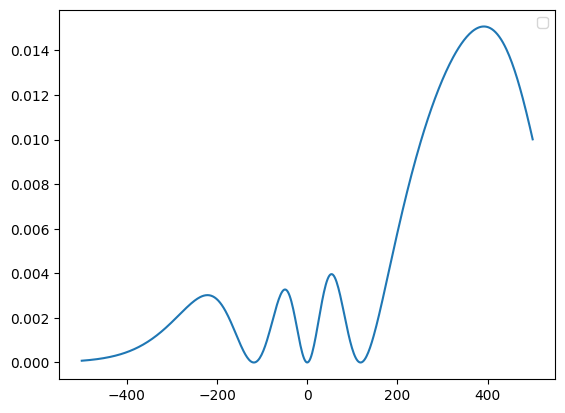

In [42]:
center = (time[0] + time[-1]) / 2
def Li_2(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_3(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_4(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_5(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
    return vectorized_polylog(values)
def Li_6(values):
    vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
    return vectorized_polylog(values)

top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
def f(t):
    f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
    f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
    f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
    return 350*(f_3 + f_2 + f_1)/9/np.pi**6
bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))

plt.plot(time, top/bottom,)
plt.legend()
plt.show()


In [43]:
def gamma_t(time, const, plot=0, form="sech",):
        center = (time[0] + time[-1]) / 2
        def Li_2(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_3(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_4(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_5(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        def Li_6(values):
            vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
            return vectorized_polylog(values)
        if form=="sech_0":
            top = (const/2)/(np.cosh(const*(time-center)))**2
            bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center)))
        elif form=="sech_1":                                                      
            top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
            def f(t):
                return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
            bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
        elif form=="sech_2":                                                    
            top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
            def f(t):
                f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
                f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
                f_0 = np.pi**4*np.tanh(t)/144
                return 45*(f_2 + f_1 + f_0)/2/np.pi**4
            bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
        elif form=="sech_3":
            top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
            def f(t):
                f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
                f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
                f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
                return 350*(f_3 + f_2 + f_1)/9/np.pi**6
            bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
        if plot:
            plt.figure(figsize=(6,2))
            plt.plot(time, top/bottom/2/np.pi)
            plt.xlabel("Time")
            plt.ylabel("Amplitude")
            plt.show()
        return top/bottom/2/np.pi

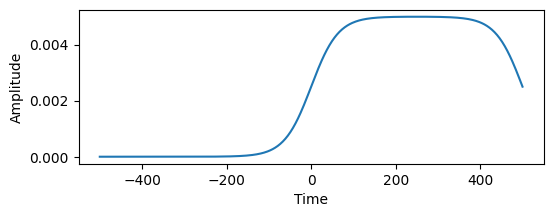

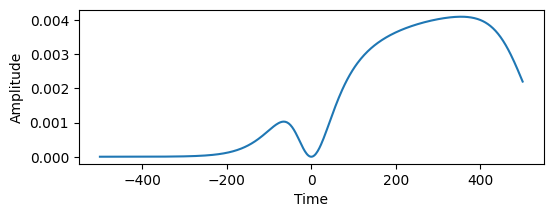

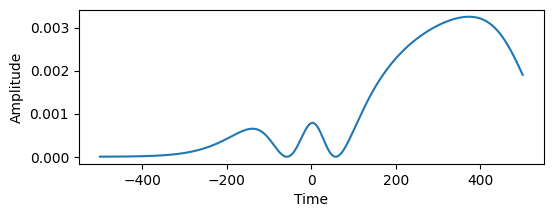

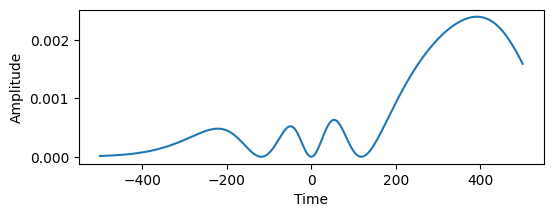

(array([7.53508411e-10, 8.02472783e-10, 8.54618950e-10, 9.10153671e-10,
        9.69297140e-10, 1.03228386e-09, 1.09936357e-09, 1.17080225e-09,
        1.24688314e-09, 1.32790791e-09, 1.41419781e-09, 1.50609500e-09,
        1.60396382e-09, 1.70819234e-09, 1.81919382e-09, 1.93740838e-09,
        2.06330473e-09, 2.19738206e-09, 2.34017197e-09, 2.49224063e-09,
        2.65419098e-09, 2.82666516e-09, 3.01034701e-09, 3.20596484e-09,
        3.41429427e-09, 3.63616131e-09, 3.87244566e-09, 4.12408418e-09,
        4.39207462e-09, 4.67747954e-09, 4.98143057e-09, 5.30513287e-09,
        5.64986989e-09, 6.01700852e-09, 6.40800444e-09, 6.82440794e-09,
        7.26787003e-09, 7.74014903e-09, 8.24311750e-09, 8.77876969e-09,
        9.34922943e-09, 9.95675857e-09, 1.06037659e-08, 1.12928168e-08,
        1.20266433e-08, 1.28081550e-08, 1.36404505e-08, 1.45268298e-08,
        1.54708073e-08, 1.64761259e-08, 1.75467715e-08, 1.86869891e-08,
        1.99012997e-08, 2.11945177e-08, 2.25717707e-08, 2.403851

In [44]:
time = np.linspace(-500, 500, 500)
const = 2.5e-3 * 2 * np.pi
gamma_t(time, const, plot=1, form="sech_0",), gamma_t(time, const, plot=1, form="sech_1",), gamma_t(time, const, plot=1, form="sech_2",), gamma_t(time, const, plot=1, form="sech_3",)

In [12]:
def polynomial_even(x, a0, a2, a4, a6, a8, a10):
    return a0 + a2*x**2 + a4*x**4 + a6*x**6 + a8*x**8 + a10*x**10
def guess_params_plev():
    par_ini = {'a0': 0, 'a2': 0, 'a4': 0, 'a6': 0, 'a8': 0, 'a10':0}
    par_max = {'a0': 1,'a2': np.inf,'a4': np.inf,'a6': np.inf,'a8': np.inf,'a10': np.inf,}
    par_min = {'a0': 0,'a8': 0,'a2': 0,'a10': 0,'a4': 0,'a6': 0,}
    par_vary = {'a0': 0, 'a2': 1, 'a4': 1, 'a6': 1, 'a8': 1, 'a10':1,}
    return par_ini,par_max,par_min,par_vary
def polynomial_even_fit(data, x,):
    model = lmf.Model(polynomial_even)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_plev()
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, x=x, params=params, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    print(result.params.valuesdict())
    return result

In [ ]:
def generate_control_pulse(self, fogi_lo, target_freq, duration, const, form="sech", plot=True, tr=True):
        time = np.arange(duration)
        Gammas = [0]
        fogi_freq_shifted = []
        amps = list(self.amps_dict.values())
        amps.insert(0, 0)
        for k, v in self.results_dict.items():
            photon_freqs = v["photon_freqs"]
            fogi_freqs = v["fogi_freqs"]
            decay_rates = v["decay_rates"]
            photonfreq_to_decayrate = interpolate.interp1d(photon_freqs, decay_rates, bounds_error=False, fill_value=(decay_rates[-1], decay_rates[0]))
            Gammas.append(photonfreq_to_decayrate(target_freq))
            photonfreq_to_fogifreq = interpolate.interp1d(photon_freqs, fogi_freqs, bounds_error=False, fill_value=(fogi_freqs[-1], fogi_freqs[0]))
            fogi_freq_shifted.append(photonfreq_to_fogifreq(target_freq))
        # envelope
        fogi_freq_shifted.insert(0, fogi_freq_shifted[0])
        # print(Gammas, amps)
        res = polynomial_even_fit(x=amps, data=Gammas)
        c = tuple(res.params.valuesdict().values())
        x = np.linspace(0, amps[-1], 10001)
        Gamma_to_amp = interpolate.interp1d(polynomial_even(x, c[0], c[1], c[2], c[3], c[4], c[5]),
                                             x, bounds_error=False, fill_value=(0, amps[-1]))
        AWGamp_of_time = lambda time:Gamma_to_amp(self.gamma_t(time, const=const, form=form))

        if tr:                                              ####### changed by Sunada
            envelope = AWGamp_of_time(time)[::-1]
        else:
            envelope = AWGamp_of_time(time)

        if plot:
            fig = plt.figure(figsize = (6.5, 3))
            ax = fig.add_subplot(1, 2, 1)
            ax.plot(amps, res.best_fit * 1e3, )
            ax.plot(amps, np.array(Gammas)*1e3,'ro')
            ax.set_xlabel('Drive amplitude (V)')
            ax.set_ylabel('$\Gamma_{\mathrm{f}}$ (MHz)')
            virtual_Gamma = np.linspace(0, 20e-3, 10001)
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(virtual_Gamma, Gamma_to_amp(virtual_Gamma),'r-', label='fit')
            ax2.plot(Gammas, amps, 'ko')
            ax2.set_ylabel('Drive amplitude (V)')
            ax2.set_xlabel('$\Gamma_{\mathrm{f}}$ (GHz)')
            plt.show()

            fig = plt.figure(figsize = (6.5, 2))
            ax = fig.add_subplot(1, 2, 1)
            ax2 = fig.add_subplot(1, 2, 2)
            ax.plot(time, envelope)
            ax.set_title('AWGamplitude vs time')
            ax2.plot(time, 1/np.cosh(const * (time - duration/2)))
            # print(time, const, duration)
            ax2.set_title('target shape')
            plt.show()

        # fogi frequency
        fogi_freq_of_AWGamp = interpolate.interp1d(amps, fogi_freq_shifted, bounds_error=False, 
                                                   fill_value=(fogi_freq_shifted[0], fogi_freq_shifted[-1]))
        
        def fogi_freq_of_time(time):
            if tr:
                f_freq = fogi_freq_of_AWGamp(AWGamp_of_time(time)[::-1])
            else:
                f_freq = fogi_freq_of_AWGamp(AWGamp_of_time(time))
            return f_freq
        fogi_frequency = fogi_freq_of_time(time) 
        
        if plot:
            fig = plt.figure(figsize=(5, 2))
            ax = fig.add_subplot(1, 2, 1)
            ax.plot(amps, fogi_freq_of_AWGamp(amps), "ro", ls="--")
            ax.set_xlabel('Drive amplitude (V)')
            ax.set_ylabel('$\Gamma_{\mathrm{ph}}$')
            ax2 = fig.add_subplot(1, 2, 2)
            ax2.plot(time, fogi_frequency) 
            ax2.set_xlabel('Time')
            ax2.set_ylabel('Momentary frequency')
            plt.show()

        # generation
        phase_of_time=[0]
        for i in range(1,len(time)):
            next_phi = phase_of_time[i-1]+(fogi_frequency[i] - fogi_lo) 
            phase_of_time.append(next_phi)
        phase_of_time = np.array(phase_of_time)
        if form == "anti_sech":                                 ### changed by Sunada
            for i in range(int(len(time)/2), len(time)):
                envelope[i] = -envelope[i]
        waveform_at_AWG = envelope*np.exp(2j * np.pi * phase_of_time) 
        if plot:
            plt.figure(figsize=(4, 3))
            plt.plot(time,waveform_at_AWG.real)
            plt.plot(time,waveform_at_AWG.imag)
            plt.plot(time,envelope)
            plt.show()
        return waveform_at_AWG